### Verifica a localização do dataset

In [3]:
from pathlib import Path
from PIL import Image

diretorio_atual = Path.cwd()
raiz_projeto = None

for candidato in (diretorio_atual, *diretorio_atual.parents):
    if ( candidato / "UFPR-ALPR dataset" ).is_dir():
        raiz_projeto = candidato
        break
if raiz_projeto is None:
    raise FileNotFoundError(f"Dataset não encontrado a partir de {diretorio_atual}")

diretorio_dataset = raiz_projeto / "UFPR-ALPR dataset"

print(f"Raiz onde está o conjunto de dados: {raiz_projeto}")
print(f"Caminho dataset:{diretorio_dataset}")

Raiz onde está o conjunto de dados: c:\Users\igorm\Documents\programacao\modelo-placa
Caminho dataset:c:\Users\igorm\Documents\programacao\modelo-placa\UFPR-ALPR dataset


### Normaliza uma amostra para garantir integridade

In [4]:
caminho_anotacao = sorted(
    (diretorio_dataset / "training").rglob("*.txt")
)[0]

caminho_imagem = caminho_anotacao.with_suffix(".png")

campos = {}

for linha in caminho_anotacao.read_text(encoding="utf-8").splitlines():
    if linha.strip():
        chave, valor = linha.split(":", maxsplit=1)
        campos[chave.strip()] = valor.strip()

cantos = []

for ponto in campos["corners"].split():
    x, y = ponto.split(",")
    cantos.append((int(x), int(y)))

with Image.open(caminho_imagem) as imagem:
    largura_imagem, altura_imagem = imagem.size

# Retângulo alinhado aos eixos que engloba os quatro cantos.
x_min = min(x for x, y in cantos)
x_max = max(x for x, y in cantos)
y_min = min(y for x, y in cantos)
y_max = max(y for x, y in cantos)

if not (
    0 <= x_min < x_max <= largura_imagem
    and 0 <= y_min < y_max <= altura_imagem
):
    raise ValueError(f"Caixa inválida: {caminho_anotacao}")

centro_x = ((x_min + x_max) / 2) / largura_imagem
centro_y = ((y_min + y_max) / 2) / altura_imagem
largura_caixa = (x_max - x_min) / largura_imagem
altura_caixa = (y_max - y_min) / altura_imagem

linha_yolo = (
    f"0 {centro_x:.6f} {centro_y:.6f} "
    f"{largura_caixa:.6f} {altura_caixa:.6f}"
)

print(f"Imagem: {caminho_imagem.name}")
print(f"Dimensões: {largura_imagem} × {altura_imagem}")
print(f"Caixa em pixels: {(x_min, y_min, x_max, y_max)}")
print(f"Anotação YOLO: {linha_yolo}")

Imagem: track0001[01].png
Dimensões: 1920 × 1080
Caixa em pixels: (912, 526, 986, 553)
Anotação YOLO: 0 0.494271 0.499537 0.038542 0.025000


### Faz o processo inverso e plota na imagem para fins de teste

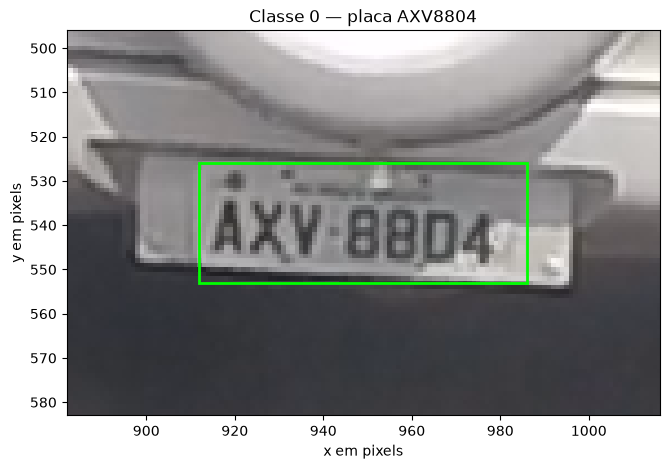

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Lê a representação que será usada no arquivo de anotação.
classe, cx, cy, largura, altura = linha_yolo.split()

cx = float(cx) * largura_imagem
cy = float(cy) * altura_imagem
largura = float(largura) * largura_imagem
altura = float(altura) * altura_imagem

# Rectangle recebe o canto superior esquerdo, não o centro.
x_esquerda = cx - largura / 2
y_topo = cy - altura / 2

with Image.open(caminho_imagem) as arquivo:
    imagem_visualizacao = arquivo.convert("RGB")

fig, ax = plt.subplots(figsize=(10, 5))

ax.imshow(imagem_visualizacao)

retangulo = Rectangle(
    (x_esquerda, y_topo),
    largura,
    altura,
    fill=False,
    edgecolor="lime",
    linewidth=2,
)

ax.add_patch(retangulo)

# Aproxima a visualização da placa sem alterar a imagem.
margem = 30
ax.set_xlim(
    max(0, x_esquerda - margem),
    min(largura_imagem, x_esquerda + largura + margem),
)
ax.set_ylim(
    min(altura_imagem, y_topo + altura + margem),
    max(0, y_topo - margem),
)

ax.set_title(f"Classe {classe} — placa {campos['plate']}")
ax.set_xlabel("x em pixels")
ax.set_ylabel("y em pixels")

plt.show()

### Função de conversão 

In [6]:
def converter_anotacao_yolo(caminho_anotacao):
    caminho_anotacao = Path(caminho_anotacao)
    caminho_imagem = caminho_anotacao.with_suffix(".png")

    campos = {}

    for linha in caminho_anotacao.read_text(encoding="utf-8").splitlines():
        if not linha.strip():
            continue

        chave, valor = linha.split(":", maxsplit=1)
        campos[chave.strip()] = valor.strip()

    if "corners" not in campos:
        raise ValueError(f"Campo corners ausente: {caminho_anotacao}")

    cantos = []

    for ponto in campos["corners"].split():
        x, y = ponto.split(",")
        cantos.append((int(x), int(y)))

    if len(cantos) != 4:
        raise ValueError(f"Esperados quatro cantos: {caminho_anotacao}")

    with Image.open(caminho_imagem) as imagem:
        largura_imagem, altura_imagem = imagem.size

    for x, y in cantos:
        if not (0 <= x < largura_imagem and 0 <= y < altura_imagem):
            raise ValueError(
                f"Canto fora da imagem: {(x, y)} em {caminho_anotacao}"
            )

    x_min = min(x for x, y in cantos)
    x_max = max(x for x, y in cantos)
    y_min = min(y for x, y in cantos)
    y_max = max(y for x, y in cantos)

    if x_min >= x_max or y_min >= y_max:
        raise ValueError(f"Caixa sem área: {caminho_anotacao}")

    centro_x = ((x_min + x_max) / 2) / largura_imagem
    centro_y = ((y_min + y_max) / 2) / altura_imagem
    largura_caixa = (x_max - x_min) / largura_imagem
    altura_caixa = (y_max - y_min) / altura_imagem

    return (
        f"0 {centro_x:.6f} {centro_y:.6f} "
        f"{largura_caixa:.6f} {altura_caixa:.6f}"
    )


resultado = converter_anotacao_yolo(caminho_anotacao)
print(resultado)

0 0.494271 0.499537 0.038542 0.025000


### Convertemos tudo mas sem copiar nada para garantir integridade dos dados

In [7]:
anotacoes_convertidas = []
erros_conversao = []

for conjunto in ("training", "validation", "testing"):
    pasta = diretorio_dataset / conjunto
    quantidade_convertida = 0

    for caminho in sorted(pasta.rglob("*.txt")):
        try:
            linha_yolo = converter_anotacao_yolo(caminho)

        except (ValueError, OSError) as erro:
            erros_conversao.append({
                "arquivo": caminho,
                "erro": str(erro),
            })
            continue

        anotacoes_convertidas.append({
            "conjunto": conjunto,
            "caminho_relativo": caminho.relative_to(pasta),
            "caminho_imagem": caminho.with_suffix(".png"),
            "linha_yolo": linha_yolo,
        })

        quantidade_convertida += 1

    print(f"{conjunto}: {quantidade_convertida} anotações convertidas")

print(f"\nTotal convertido: {len(anotacoes_convertidas)}")
print(f"Total de erros: {len(erros_conversao)}")

for registro in erros_conversao[:10]:
    print(f"\nArquivo: {registro['arquivo']}")
    print(f"Erro: {registro['erro']}")

training: 1800 anotações convertidas
validation: 900 anotações convertidas
testing: 1800 anotações convertidas

Total convertido: 4500
Total de erros: 0


### Construção dataset Yolo

In [8]:
from shutil import copy2

diretorio_yolo = raiz_projeto / "dados_yolo"

if erros_conversao:
    raise RuntimeError("Resolva os erros de conversão antes de exportar.")

if len(anotacoes_convertidas) != 4500:
    raise RuntimeError("A lista de conversão não contém as 4.500 anotações.")

if diretorio_yolo.exists():
    raise FileExistsError(
        f"A pasta já existe: {diretorio_yolo}. "
        "Confira seu conteúdo antes de executar novamente."
    )

diretorio_yolo.mkdir()

for registro in anotacoes_convertidas:
    conjunto = registro["conjunto"]
    caminho_relativo = registro["caminho_relativo"]

    destino_imagem = (
        diretorio_yolo
        / "images"
        / conjunto
        / caminho_relativo.with_suffix(".png")
    )

    destino_anotacao = (
        diretorio_yolo
        / "labels"
        / conjunto
        / caminho_relativo
    )

    destino_imagem.parent.mkdir(parents=True, exist_ok=True)
    destino_anotacao.parent.mkdir(parents=True, exist_ok=True)

    copy2(registro["caminho_imagem"], destino_imagem)

    destino_anotacao.write_text(
        registro["linha_yolo"] + "\n",
        encoding="utf-8",
    )

for conjunto in ("training", "validation", "testing"):
    quantidade_imagens = sum(
        1 for _ in (diretorio_yolo / "images" / conjunto).rglob("*.png")
    )
    quantidade_anotacoes = sum(
        1 for _ in (diretorio_yolo / "labels" / conjunto).rglob("*.txt")
    )

    print(
        f"{conjunto}: {quantidade_imagens} imagens | "
        f"{quantidade_anotacoes} anotações"
    )

print(f"\nDataset exportado para: {diretorio_yolo}")

training: 1800 imagens | 1800 anotações
validation: 900 imagens | 900 anotações
testing: 1800 imagens | 1800 anotações

Dataset exportado para: c:\Users\igorm\Documents\programacao\modelo-placa\dados_yolo


### Contrução do dataset_yaml

In [9]:
caminho_yaml = diretorio_yolo / "dataset.yaml"

conteudo_yaml = f"""path: "{diretorio_yolo.resolve().as_posix()}"

train: images/training
val: images/validation
test: images/testing

names:
  0: placa
"""

caminho_yaml.write_text(conteudo_yaml, encoding="utf-8")

print(conteudo_yaml)
print(f"Configuração salva em: {caminho_yaml}")

path: "C:/Users/igorm/Documents/programacao/modelo-placa/dados_yolo"

train: images/training
val: images/validation
test: images/testing

names:
  0: placa

Configuração salva em: c:\Users\igorm\Documents\programacao\modelo-placa\dados_yolo\dataset.yaml


In [11]:
# Recarrega os pesos originais: não continua a execução de verificação.
modelo = YOLO("yolo26n.pt")

resultado_treino = modelo.train(
    data=str(caminho_yaml),
    epochs=50,
    patience=10,
    imgsz=640,
    batch=4,
    device=0,
    workers=0,
    cache=False,
    fliplr=0.0,
    mosaic=0.0,
    project=str(raiz_projeto / "runs"),
    name="baseline_yolo26n_640",
    seed=42,
)

Ultralytics 8.4.165  Python-3.14.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\igorm\Documents\programacao\modelo-placa\dados_yolo\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0

KeyboardInterrupt: 